In [1]:
import os
import sys
# Get the directory of the current file
current_dir = os.path.dirname(os.path.abspath('__file__'))

# Get the parent directory
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to sys.path
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Add the source directory to sys.path
source_dir = os.path.join(parent_dir, 'src')
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)
print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from sources.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *
import os
import sys


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "test_changes"



## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TXY")
lattice_slab = Lattice(type="TXY", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()



bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": InP})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": air})
hole2_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": height_slab, "material": air})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D, hole2_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab, hole2_slab])

## Define the simulation

configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=3, 
    extra_runner_command = "(output-at-kpoint (vector3 0 0 0) fix-efield-phase output-efield)"
)



mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)

Included '/zhome/2f/7/202918/phc_nzi/src' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.
Epsilon of InP:  9.61
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.3)', '(define-param r2 0.2)']


In [2]:
from src.simulation_handler import Simulation
sim = Simulation( "test2", script_slab)
#sim.run_hpc_lsf()



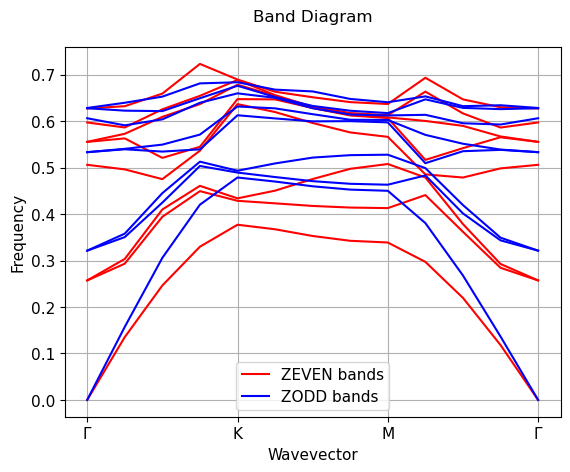

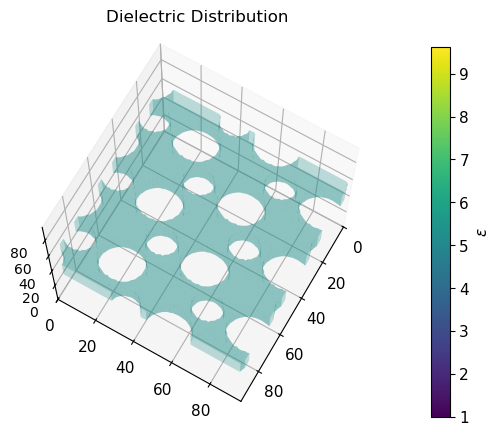

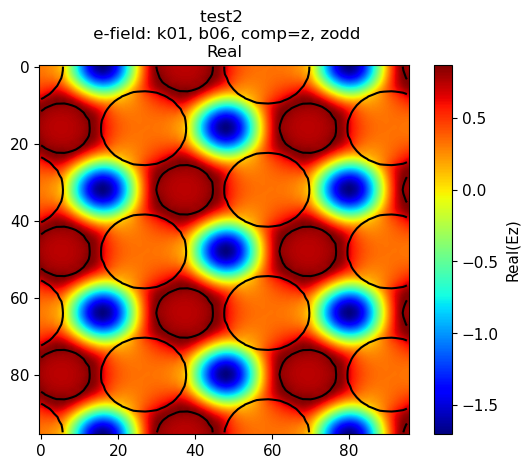

In [4]:
from src.simulation_viewer import SimulationViewer
viewr = SimulationViewer(sim)
viewr.plot_band_diagram(k_points_path=k_points, polarization="zeven", color = "red")
viewr.plot_band_diagram(k_points_path=k_points, polarization="zodd", color = "blue")
viewr.show()
viewr.figure()
viewr.plot_epsilon_3d(alpha = 0.3)
viewr.rotate(30, 70)
viewr.show()
viewr.figure()
viewr.plot_field_2d(1,6, "e", "z", "zodd", nonbloch=False, operation=np.real, overlay_epsilon_contour=True, axis= 2)
